In [1]:
import sys

# Change path to wherever you have repo locally
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src')


from Stage3_Interpretation.A_Plotting.src import (load_stablity_error_data, plot_stablity_error,\
                               load_enrichment_data, plot_enrichment,\
                               load_perturbation_data, plot_perturbation,\
                               load_explained_variance_data,plot_explained_variance, programs_dotplots, \
                               plot_k_selection_panel,plot_k_selection_panel_no_traits
                          )

/home/users/ymo/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
output_directory = "/oak/stanford/groups/engreitz/Users/ymo/Project/Morphic_MSK_KO/Result"
run_name = "052126_MSK_KO_torch_batch"
folder = f"{output_directory}/{run_name}/Evaluation"
K = [10, 20, 30, 50, 60, 70, 80, 90, 100]
sel_threshs = [0.6]

# Grouping variable used in plots (must be a column in mdata['rna'].obs)
groupby = "batch"
conditions = ['D-1', 'D3', 'D7', 'D11', 'D18']

# Optional pre-computed stability/error file (TSV or NPZ). Set to a path to bypass cnmf.consensus().
# Useful for torch-cNMF runs where the cnmf package is not installed.
stability_file = None

# Toggle per-(K, sel_thresh) program dotplots. Requires the inference h5mu to exist for each pair.
# Default off; set True to enable.
run_program_dotplot = False

# Stability & Error

In [ ]:
# For torch-cNMF runs where the cnmf package is not installed, set stability_file (above)
# to a pre-computed TSV/NPZ stats file. Otherwise this calls cnmf.consensus() internally.
stats = load_stablity_error_data(
    output_directory=f'{output_directory}/{run_name}',
    run_name='Inference',
    components=K,
    stability_file=stability_file,
)
stats

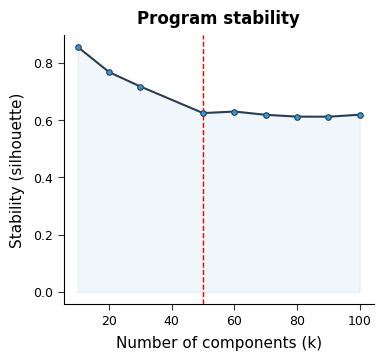

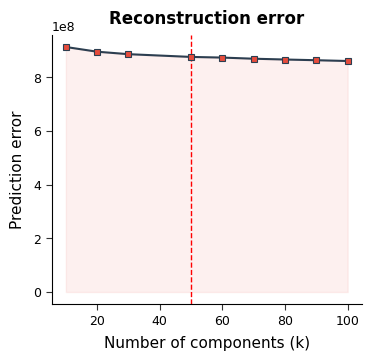

In [7]:
plot_stablity_error(stats, selected_k = 50)

# Enrichement tests

In [ ]:
count_df = load_enrichment_data(folder, components = K,  sel_thresh = 0.6, pval = 0.05)

plot_enrichment(count_df, selected_k = None)

# Perturbation

In [ ]:
test_stats_df = load_perturbation_data(folder, components = K, pval = 0.05, sel_thresh = 0.6, conditions = conditions)

plot_perturbation(test_stats_df, pval = 0.05, selected_k = None)

# Explained Variance

In [ ]:
stats_EV = load_explained_variance_data(folder, components=K, sel_thresh = 0.6)

plot_explained_variance(stats_EV, selected_k = None)

# All plots

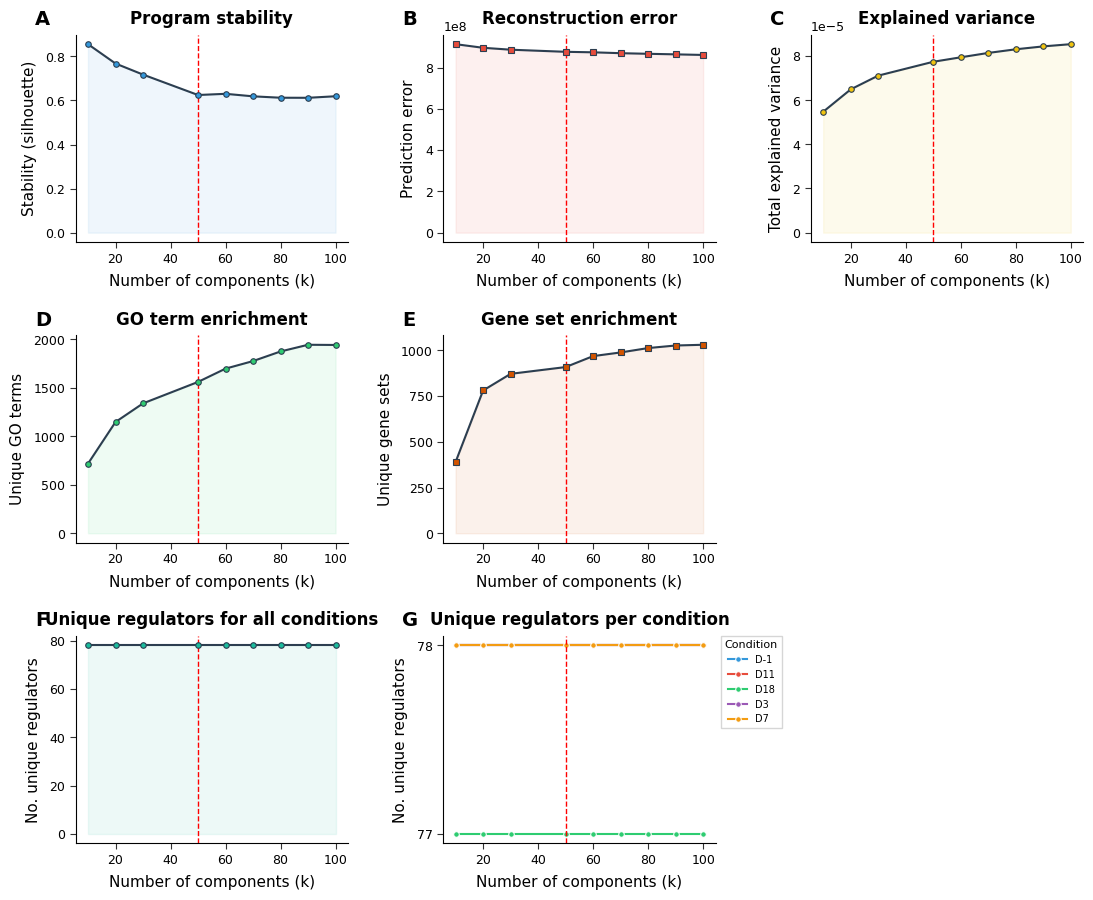

In [9]:
plot_k_selection_panel_no_traits(stats, count_df, test_stats_df, stats_EV,
                           pval=0.05, folder_name=None, file_name=None, selected_k=50)

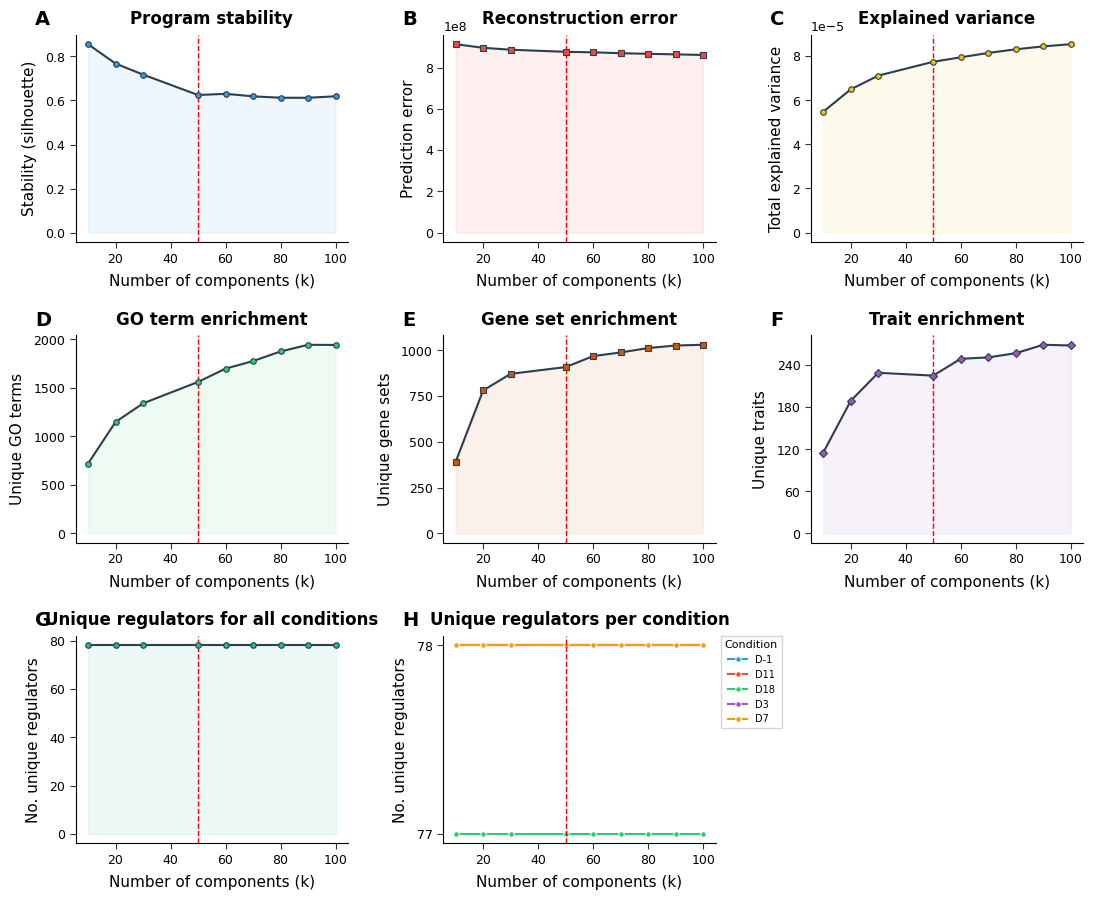

In [10]:
plot_k_selection_panel(stats, count_df, test_stats_df, stats_EV,
                           pval=0.05, folder_name=None, file_name=None, selected_k=50)

# plot dot plots

In [ ]:
# Per-(K, sel_thresh) program dotplots. Optional — needs the inference h5mu for each pair.
# Missing h5mu paths now skip gracefully (warning) instead of crashing.
if run_program_dotplot:
    for sel_thresh in sel_threshs:
        for k in K:
            fig = programs_dotplots(
                k, output_directory, run_name,
                sel_thresh=sel_thresh, groupby=groupby,
                figsize=(4, 15),
            )
else:
    print("Skipping program dotplots (set run_program_dotplot = True to enable).")

# Motif (working in progress for complie the results)

In [20]:
def collect_motif_data(k, path):

    motif_enrichment_data = []

    path = f'{path}/{k}'

    # import data 
    for fil in os.listdir(path):
        if 'motif_enrichment' in fil:
            motif_enrichment_data_ = pd.read_csv('{}/{}'.format(path,fil), sep='\t')
            motif_enrichment_data_['sample'] = fil.split('sample_')[-1].split('_motif')[0]
            if 'promoter' in fil:
                motif_enrichment_data_['class'] = 'promoter'
            elif 'enhancer' in fil:
                motif_enrichment_data_['class'] = 'enhancer'            

            motif_enrichment_data.append(motif_enrichment_data_)

    motif_enrichment_data = pd.concat(motif_enrichment_data, ignore_index=True)
    motif_enrichment_data.rename(columns={"adj_pval": "Adjusted P-value"}, inplace=True)

    motif_enrichment_data.to_csv(f'{path}/{k}_motif_enrichment.txt', sep='\t')
    motif_enrichment_data.loc[motif_enrichment_data['class']=='promoter'].to_csv(f'{path}/{k}_motif_enrichment_promoter.txt', sep='\t')
    motif_enrichment_data.loc[motif_enrichment_data['class']=='enhancer'].to_csv(f'{path}/{k}_motif_enrichment_enhancer.txt', sep='\t')


    # Make summary table column
    for seq_class in ['promoter', 'enhancer']:
        motif_enrichment_data_ = motif_enrichment_data.loc[motif_enrichment_data['class']==seq_class]
        motif_enrichment_data_ = motif_enrichment_data_.groupby(['sample', 'program_name', 'motif']).min().reset_index()

        motif_summary_data = pd.DataFrame(index=motif_enrichment_data_.program_name.unique(), columns=['top10_motifs', 'num_enriched_motifs'])
        for prog in motif_enrichment_data_.program_name.unique():
            motif_summary_data_ = motif_enrichment_data_.loc[(motif_enrichment_data_.program_name==prog) & ((motif_enrichment_data_["Adjusted P-value"]<=0.05))]
            motif_summary_data_ = motif_summary_data_.sort_values('stat', ascending=False).head(10).motif.values
            motif_summary_data.loc[prog,'top10_motifs'] = ', '.join(motif_summary_data_.tolist())
            motif_summary_data.loc[prog, 'num_enriched_motifs'] = motif_enrichment_data_.loc[(motif_enrichment_data_.program_name==prog) & ((motif_enrichment_data_.adj_pval<=0.05))].shape[0]
            
        motif_summary_data.to_csv('{}/motif_summary_data_{}.txt'.format(path,seq_class), sep='\t')
        

def collect_motif_all(path, components = [30, 50, 60, 80, 100, 200, 250, 300]):

    for k in components:
        collect_motif_data(k, path)
    
collect_motif_all(path)

In [ ]:
path = '/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Results/torch-cNMF_evaluation/090425_100k_cells_10iter_torch_mu_online/Evaluation/'


collect_motif_data(50,path)

In [4]:
    
# # Copy out to dashboard
# out_dir = '../../shared/250110_ipsc_ec_dashboard_setup/cNMF_100/'
# for fil in os.listdir('cNMF_100'):
#     if 'motif_' in fil:
#         class_ = fil.split('_')[1]
#         name = fil.split('_sample_')[1]
#         new_nam = f'cNMF_100_{class_}_test_pearsonr_sample_{name}'
#         if not name.startswith('D0'):
#             new_nam = new_nam.replace('sample_', 'sample_sample_')
#         os.system('cp {} {}'.format(os.path.join('cNMF_100', fil),
#                                     os.path.join(out_dir, new_nam)))